
# CV bias versus posterior-median PE bias for `inj_id = 4`



In [1]:

from pathlib import Path
from matplotlib.backends.backend_pdf import PdfPages

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 200)
pd.set_option("display.width", 180)



## 1. File paths and configuration

The notebook first checks the original uploaded-file paths. Alternative local and cluster paths are also provided so the notebook can be moved without rewriting its analysis.


In [2]:

INJ_ID = 4

CV_PATH_CANDIDATES = [
    Path("/pbs/home/a/amahdi/pySEOBNR_deviation/Injection set/SEOBNRv5HMROM_times_pSEOB_ratio_phase_with_denom_condition_domega_dtau_scan_M1e6/run_data/bias_syst_recovery/cv_bias_sigma_fti_all_params_all_inj_ids.csv"
    ),
]

MEDIAN_PE_PATH_CANDIDATES = [
    Path("/pbs/home/a/amahdi/PE_for_my_work/config_files/M1e6_SEOBv5_id_4/normalized_bias_corner_plots/tables/median_bias_over_sigma_PE.csv"
    ),
]

OUTPUT_DIR = Path(f"cv_vs_median_pe_comparison_inj_id_{INJ_ID}")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

def resolve_path(candidates, label):
    for candidate in candidates:
        if candidate.exists():
            print(f"{label}: {candidate.resolve()}")
            return candidate

    checked = "\n".join(f"  - {candidate}" for candidate in candidates)
    raise FileNotFoundError(
        f"Could not find {label}. The following paths were checked:\n{checked}"
    )

CV_PATH = resolve_path(CV_PATH_CANDIDATES, "CV-bias table")
MEDIAN_PE_PATH = resolve_path(
    MEDIAN_PE_PATH_CANDIDATES,
    "posterior-median PE-bias table",
)

print(f"Output directory: {OUTPUT_DIR.resolve()}")


CV-bias table: /pbs/home/a/amahdi/pySEOBNR_deviation/Injection set/SEOBNRv5HMROM_times_pSEOB_ratio_phase_with_denom_condition_domega_dtau_scan_M1e6/run_data/bias_syst_recovery/cv_bias_sigma_fti_all_params_all_inj_ids.csv
posterior-median PE-bias table: /pbs/home/a/amahdi/PE_for_my_work/config_files/M1e6_SEOBv5_id_4/normalized_bias_corner_plots/tables/median_bias_over_sigma_PE.csv
Output directory: /pbs/home/a/amahdi/PE_for_my_work/Comparison/cv_vs_median_pe_comparison_inj_id_4



## 2. Load and validate the input tables


In [3]:

cv_all = pd.read_csv(CV_PATH)
median_pe = pd.read_csv(MEDIAN_PE_PATH)

required_cv_columns = {
    "inj_id",
    "d_omega",
    "d_tau",
    "fti_case",
    "fti_value",
    "parameter",
    "Delta_theta_over_sigma",
    "Delta_theta",
    "sigma",
    "is_active_fti_parameter",
}

required_median_columns = {
    "active_fti_run",
    "parameter",
    "posterior_source",
    "true_value",
    "posterior_median",
    "median_minus_true",
    "sigma_method",
    "sigma_PE",
    "median_bias_over_sigma_PE",
}

missing_cv = required_cv_columns.difference(cv_all.columns)
missing_median = required_median_columns.difference(median_pe.columns)

if missing_cv:
    raise ValueError(f"Missing CV columns: {sorted(missing_cv)}")

if missing_median:
    raise ValueError(
        f"Missing posterior-median PE columns: {sorted(missing_median)}"
    )

print(f"Complete CV table:          {cv_all.shape[0]} rows")
print(f"Posterior-median PE table:  {median_pe.shape[0]} rows")
print(
    "Available CV injection IDs:",
    sorted(cv_all["inj_id"].dropna().unique()),
)


Complete CV table:          720 rows
Posterior-median PE table:  144 rows
Available CV injection IDs: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]



## 3. Filter the CV results to `inj_id = 4` and match corresponding cases

The matching keys are:

- `fti_case` in the CV table versus `active_fti_run` in the PE table;
- `parameter` in both tables.


In [4]:

cv = cv_all.loc[cv_all["inj_id"] == INJ_ID].copy()

if cv.empty:
    raise ValueError(f"No CV rows were found for inj_id = {INJ_ID}.")

cv_key = ["fti_case", "parameter"]
median_key = ["active_fti_run", "parameter"]

if cv.duplicated(cv_key).any():
    display(cv.loc[cv.duplicated(cv_key, keep=False)].sort_values(cv_key))
    raise ValueError("Duplicate CV matching keys were found.")

if median_pe.duplicated(median_key).any():
    display(
        median_pe.loc[
            median_pe.duplicated(median_key, keep=False)
        ].sort_values(median_key)
    )
    raise ValueError("Duplicate PE matching keys were found.")

cv_for_merge = cv[
    [
        "inj_id",
        "d_omega",
        "d_tau",
        "fti_case",
        "fti_value",
        "parameter",
        "Delta_theta_over_sigma",
        "Delta_theta",
        "sigma",
        "is_active_fti_parameter",
    ]
].rename(
    columns={
        "fti_case": "active_fti_run",
        "Delta_theta_over_sigma": "CV_bias_over_sigma",
        "Delta_theta": "CV_delta_theta",
        "sigma": "sigma_CV",
    }
)

median_for_merge = median_pe[
    [
        "active_fti_run",
        "parameter",
        "posterior_source",
        "true_value",
        "posterior_median",
        "median_minus_true",
        "sigma_method",
        "sigma_PE",
        "median_bias_over_sigma_PE",
    ]
].rename(
    columns={
        "median_minus_true": "median_PE_delta_theta",
        "median_bias_over_sigma_PE": "median_PE_bias_over_sigma",
    }
)

comparison = cv_for_merge.merge(
    median_for_merge,
    on=["active_fti_run", "parameter"],
    how="outer",
    validate="one_to_one",
    indicator=True,
)

unmatched = comparison.loc[comparison["_merge"] != "both"]

if not unmatched.empty:
    display(unmatched)
    raise ValueError(
        "Some CV and PE rows could not be matched by FTI run and parameter."
    )

comparison = comparison.drop(columns="_merge")

comparison["median_PE_minus_CV"] = (
    comparison["median_PE_bias_over_sigma"]
    - comparison["CV_bias_over_sigma"]
)
comparison["absolute_difference"] = comparison[
    "median_PE_minus_CV"
].abs()

comparison["absolute_CV_bias_over_sigma"] = comparison[
    "CV_bias_over_sigma"
].abs()
comparison["absolute_median_PE_bias_over_sigma"] = comparison[
    "median_PE_bias_over_sigma"
].abs()

comparison["raw_shift_difference"] = (
    comparison["median_PE_delta_theta"]
    - comparison["CV_delta_theta"]
)
comparison["sigma_PE_over_sigma_CV"] = (
    comparison["sigma_PE"] / comparison["sigma_CV"]
)

comparison["same_sign"] = (
    np.sign(comparison["CV_bias_over_sigma"])
    == np.sign(comparison["median_PE_bias_over_sigma"])
)

run_order = list(
    dict.fromkeys(median_pe["active_fti_run"].tolist())
)

physical_parameter_order = [
    "Mchirp",
    "q",
    "chiPN",
    "chim",
    "Deltat",
    "dist",
    "inc",
    "phi",
    "lambda",
    "beta",
    "psi",
]

run_rank = {run: index for index, run in enumerate(run_order)}

def parameter_rank(row):
    parameter = row["parameter"]
    run = row["active_fti_run"]

    if parameter in physical_parameter_order:
        return physical_parameter_order.index(parameter)

    if parameter == run:
        return len(physical_parameter_order)

    return len(physical_parameter_order) + 1

comparison["_run_rank"] = comparison["active_fti_run"].map(run_rank)
comparison["_parameter_rank"] = comparison.apply(parameter_rank, axis=1)

comparison = (
    comparison.sort_values(
        ["_run_rank", "_parameter_rank", "parameter"]
    )
    .drop(columns=["_run_rank", "_parameter_rank"])
    .reset_index(drop=True)
)

print(f"CV rows retained for inj_id={INJ_ID}: {len(cv)}")
print(f"Matched rows:                       {len(comparison)}")
print(
    f"Matched FTI recovery runs:          "
    f"{comparison['active_fti_run'].nunique()}"
)
print(
    "Rows in each recovery run:",
    comparison.groupby("active_fti_run").size().unique(),
)

display(
    comparison[
        [
            "active_fti_run",
            "parameter",
            "CV_bias_over_sigma",
            "median_PE_bias_over_sigma",
            "median_PE_minus_CV",
            "sigma_CV",
            "sigma_PE",
            "is_active_fti_parameter",
        ]
    ].head(24)
)


CV rows retained for inj_id=4: 144
Matched rows:                       144
Matched FTI recovery runs:          12
Rows in each recovery run: [12]


,active_fti_run,parameter,CV_bias_over_sigma,median_PE_bias_over_sigma,median_PE_minus_CV,sigma_CV,sigma_PE,is_active_fti_parameter
0,fti_dchi0v,Mchirp,-1.551332e-06,-0.013709,-0.013708,89.986329,91.682323,False
1,fti_dchi0v,q,2.833692e-06,0.048201,0.048198,0.004663,0.004675,False
2,fti_dchi0v,chiPN,3.055816e-06,0.020215,0.020212,0.000302,0.000302,False
3,fti_dchi0v,chim,-9.947207e-07,-0.007775,-0.007774,0.002627,0.002634,False
4,fti_dchi0v,Deltat,-7.952803e-04,0.043801,0.044596,0.095381,0.096716,False
5,fti_dchi0v,dist,5.677580e-06,0.012164,0.012159,28.008115,28.034454,False
6,fti_dchi0v,inc,-5.608160e-06,-0.008433,-0.008427,0.002839,0.002836,False
7,fti_dchi0v,phi,1.136857e-04,0.031422,0.031308,0.015781,0.015858,False
8,fti_dchi0v,lambda,6.069870e-06,0.012193,0.012187,0.003373,0.003394,False
9,fti_dchi0v,beta,2.081742e-06,0.002058,0.002056,0.001704,0.001729,False



## 4. Save the complete matched comparison table


In [5]:

comparison_path = (
    OUTPUT_DIR
    / f"cv_vs_median_pe_bias_over_sigma_inj_id_{INJ_ID}.csv"
)
comparison.to_csv(comparison_path, index=False)

print(f"Saved: {comparison_path.resolve()}")


Saved: /pbs/home/a/amahdi/PE_for_my_work/Comparison/cv_vs_median_pe_comparison_inj_id_4/cv_vs_median_pe_bias_over_sigma_inj_id_4.csv



## 5. Side-by-side comparison for the active FTI parameter

This section selects the active FTI parameter from each of the 12 recovery runs and places the CV and posterior-median PE biases side by side.


In [6]:

active_fti = comparison.loc[
    comparison["is_active_fti_parameter"].astype(bool)
].copy()

incorrect_active_rows = active_fti.loc[
    active_fti["parameter"] != active_fti["active_fti_run"]
]

if not incorrect_active_rows.empty:
    display(incorrect_active_rows)
    raise ValueError(
        "A row marked as the active FTI parameter does not match "
        "the corresponding FTI run name."
    )

active_fti_columns = [
    "active_fti_run",
    "parameter",
    "CV_bias_over_sigma",
    "median_PE_bias_over_sigma",
    "median_PE_minus_CV",
    "absolute_difference",
    "CV_delta_theta",
    "median_PE_delta_theta",
    "sigma_CV",
    "sigma_PE",
    "sigma_PE_over_sigma_CV",
    "same_sign",
]

active_fti_table = active_fti[
    active_fti_columns
].reset_index(drop=True)

active_fti_path = (
    OUTPUT_DIR
    / f"active_fti_cv_vs_median_pe_inj_id_{INJ_ID}.csv"
)
active_fti_table.to_csv(active_fti_path, index=False)

display(active_fti_table)
print(f"Saved: {active_fti_path.resolve()}")


,active_fti_run,parameter,CV_bias_over_sigma,median_PE_bias_over_sigma,median_PE_minus_CV,absolute_difference,CV_delta_theta,median_PE_delta_theta,sigma_CV,sigma_PE,sigma_PE_over_sigma_CV,same_sign
0,fti_dchi0v,fti_dchi0v,1.623865e-06,0.015305,0.015303,0.015303,7.452138e-10,7.155144e-06,0.000459,0.000468,1.018724,True
1,fti_dchi1v,fti_dchi1v,1.558026e-06,0.002227,0.002226,0.002226,1.066585e-09,1.519831e-06,0.000685,0.000682,0.996711,True
2,fti_dchi2v,fti_dchi2v,1.499488e-06,-0.043294,-0.043295,0.043295,6.908445e-10,-2.013881e-05,0.000461,0.000465,1.009653,False
3,fti_dchi3v,fti_dchi3v,-1.415881e-06,0.034878,0.034879,0.034879,-6.151781e-10,1.507777e-05,0.000434,0.000432,0.994975,False
4,fti_dchi4v,fti_dchi4v,1.280708e-06,-0.038739,-0.038740,0.038740,5.172933e-09,-1.561643e-04,0.004039,0.004031,0.998043,False
5,fti_dchi5lv,fti_dchi5lv,-1.106170e-06,-0.006769,-0.006768,0.006768,-8.095780e-09,-4.987369e-05,0.007319,0.007368,1.006668,True
6,fti_dchi6lv,fti_dchi6lv,-1.201487e-06,0.027248,0.027249,0.027249,-1.213684e-08,2.758490e-04,0.010102,0.010124,1.002196,False
7,fti_dchi6v,fti_dchi6v,-9.182326e-07,0.054340,0.054341,0.054341,-5.762038e-09,3.438745e-04,0.006275,0.006328,1.008447,False
8,fti_dchi7v,fti_dchi7v,7.391352e-07,-0.050811,-0.050812,0.050812,1.995342e-09,-1.361589e-04,0.002700,0.002680,0.992648,False
9,fti_dchiMinus2v,fti_dchiMinus2v,-1.110934e-06,0.002319,0.002320,0.002320,-1.225543e-12,2.627867e-09,0.000001,0.000001,1.027294,False


Saved: /pbs/home/a/amahdi/PE_for_my_work/Comparison/cv_vs_median_pe_comparison_inj_id_4/active_fti_cv_vs_median_pe_inj_id_4.csv


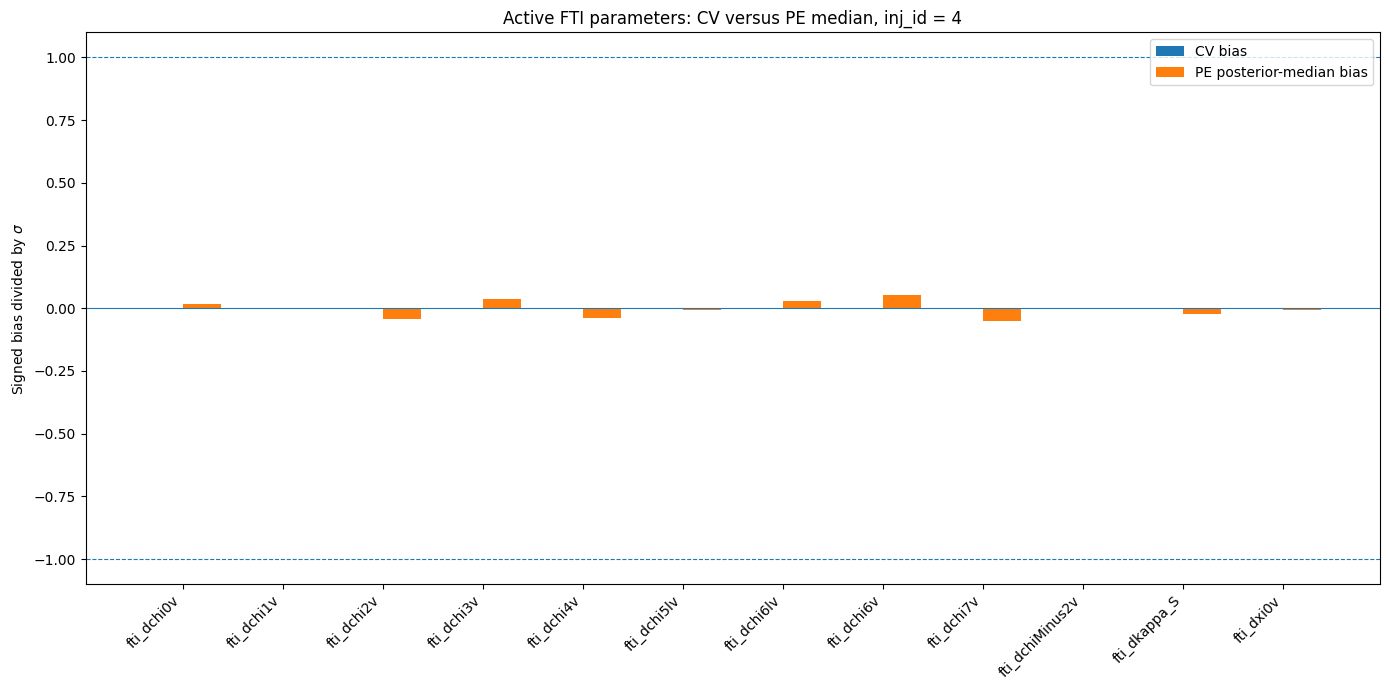

Saved: /pbs/home/a/amahdi/PE_for_my_work/Comparison/cv_vs_median_pe_comparison_inj_id_4/active_fti_cv_vs_median_pe_inj_id_4.png


In [7]:

positions = np.arange(len(active_fti_table))
bar_width = 0.38

fig, ax = plt.subplots(figsize=(14, 7))

ax.bar(
    positions - bar_width / 2,
    active_fti_table["CV_bias_over_sigma"],
    width=bar_width,
    label="CV bias",
)

ax.bar(
    positions + bar_width / 2,
    active_fti_table["median_PE_bias_over_sigma"],
    width=bar_width,
    label="PE posterior-median bias",
)

ax.axhline(0, linewidth=0.8)
ax.axhline(1, linestyle="--", linewidth=0.8)
ax.axhline(-1, linestyle="--", linewidth=0.8)

ax.set_xticks(positions)
ax.set_xticklabels(
    active_fti_table["active_fti_run"],
    rotation=45,
    ha="right",
)

ax.set_ylabel(r"Signed bias divided by $\sigma$")
ax.set_title(
    f"Active FTI parameters: CV versus PE median, inj_id = {INJ_ID}"
)
ax.legend()

fig.tight_layout()

active_plot_path = (
    OUTPUT_DIR
    / f"active_fti_cv_vs_median_pe_inj_id_{INJ_ID}.png"
)
fig.savefig(active_plot_path, dpi=200, bbox_inches="tight")
plt.show()

print(f"Saved: {active_plot_path.resolve()}")



## 6. Detailed side-by-side plots for every corresponding FTI case

Each panel contains all physical parameters and the active FTI parameter for one recovery run.


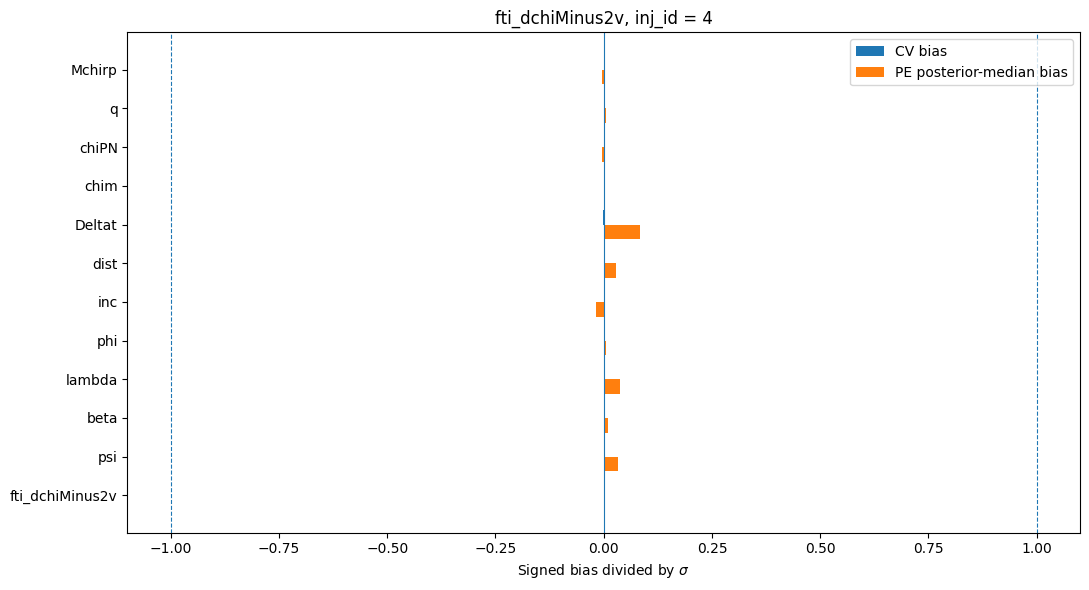

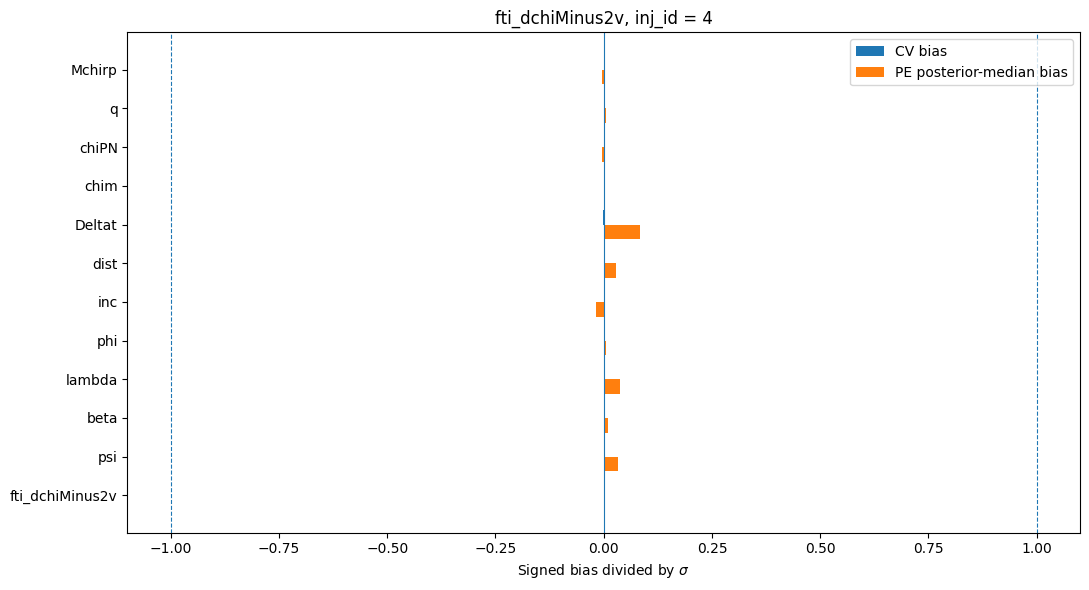

In [8]:

def make_single_run_plot(run_name, save=True, show=True):
    group = comparison.loc[
        comparison["active_fti_run"] == run_name
    ].copy()

    if group.empty:
        raise ValueError(
            f"{run_name!r} is not present. "
            f"Available runs: {run_order}"
        )

    positions = np.arange(len(group))
    bar_width = 0.38
    fig_height = max(6, 0.48 * len(group))

    fig, ax = plt.subplots(figsize=(11, fig_height))

    ax.barh(
        positions - bar_width / 2,
        group["CV_bias_over_sigma"],
        height=bar_width,
        label="CV bias",
    )

    ax.barh(
        positions + bar_width / 2,
        group["median_PE_bias_over_sigma"],
        height=bar_width,
        label="PE posterior-median bias",
    )

    ax.axvline(0, linewidth=0.8)
    ax.axvline(1, linestyle="--", linewidth=0.8)
    ax.axvline(-1, linestyle="--", linewidth=0.8)

    ax.set_yticks(positions)
    ax.set_yticklabels(group["parameter"])
    ax.invert_yaxis()

    ax.set_xlabel(r"Signed bias divided by $\sigma$")
    ax.set_title(f"{run_name}, inj_id = {INJ_ID}")
    ax.legend()

    fig.tight_layout()

    if save:
        plot_path = (
            OUTPUT_DIR
            / f"{run_name}_cv_vs_median_pe_inj_id_{INJ_ID}.png"
        )
        fig.savefig(plot_path, dpi=200, bbox_inches="tight")

    if show:
        plt.show()
    else:
        plt.close(fig)

    return fig


SELECTED_RUN = "fti_dchiMinus2v"
make_single_run_plot(SELECTED_RUN, save=True, show=True)


In [9]:

all_runs_pdf = (
    OUTPUT_DIR
    / f"all_fti_runs_cv_vs_median_pe_inj_id_{INJ_ID}.pdf"
)

with PdfPages(all_runs_pdf) as pdf:
    for run_name in run_order:
        group = comparison.loc[
            comparison["active_fti_run"] == run_name
        ].copy()

        positions = np.arange(len(group))
        bar_width = 0.38
        fig_height = max(6, 0.48 * len(group))

        fig, ax = plt.subplots(figsize=(11, fig_height))

        ax.barh(
            positions - bar_width / 2,
            group["CV_bias_over_sigma"],
            height=bar_width,
            label="CV bias",
        )

        ax.barh(
            positions + bar_width / 2,
            group["median_PE_bias_over_sigma"],
            height=bar_width,
            label="PE posterior-median bias",
        )

        ax.axvline(0, linewidth=0.8)
        ax.axvline(1, linestyle="--", linewidth=0.8)
        ax.axvline(-1, linestyle="--", linewidth=0.8)

        ax.set_yticks(positions)
        ax.set_yticklabels(group["parameter"])
        ax.invert_yaxis()

        ax.set_xlabel(r"Signed bias divided by $\sigma$")
        ax.set_title(f"{run_name}, inj_id = {INJ_ID}")
        ax.legend()

        fig.tight_layout()

        png_path = (
            OUTPUT_DIR
            / f"{run_name}_cv_vs_median_pe_inj_id_{INJ_ID}.png"
        )
        fig.savefig(png_path, dpi=200, bbox_inches="tight")
        pdf.savefig(fig, bbox_inches="tight")
        plt.close(fig)

print(f"Saved all individual plots in: {OUTPUT_DIR.resolve()}")
print(f"Saved combined PDF: {all_runs_pdf.resolve()}")


Saved all individual plots in: /pbs/home/a/amahdi/PE_for_my_work/Comparison/cv_vs_median_pe_comparison_inj_id_4
Saved combined PDF: /pbs/home/a/amahdi/PE_for_my_work/Comparison/cv_vs_median_pe_comparison_inj_id_4/all_fti_runs_cv_vs_median_pe_inj_id_4.pdf



## 7. Direct CV-versus-median scatter plot

The dashed diagonal represents exact equality between the two normalized biases.


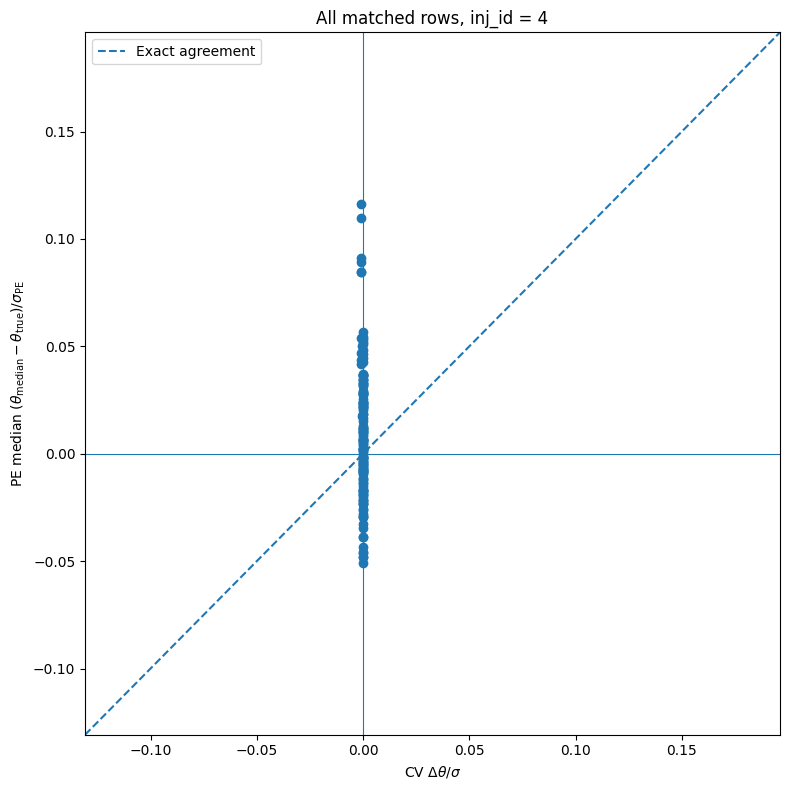

Saved: /pbs/home/a/amahdi/PE_for_my_work/Comparison/cv_vs_median_pe_comparison_inj_id_4/scatter_cv_vs_median_pe_inj_id_4.png


In [10]:

x = comparison["CV_bias_over_sigma"].to_numpy(dtype=float)
y = comparison["median_PE_bias_over_sigma"].to_numpy(dtype=float)

finite = np.isfinite(x) & np.isfinite(y)
x = x[finite]
y = y[finite]

lower = min(x.min(), y.min())
upper = max(x.max(), y.max())
padding = 0.08 * max(upper - lower, 1.0)
limits = (lower - padding, upper + padding)

fig, ax = plt.subplots(figsize=(8, 8))

ax.scatter(x, y)
ax.plot(limits, limits, linestyle="--", label="Exact agreement")
ax.axhline(0, linewidth=0.8)
ax.axvline(0, linewidth=0.8)

ax.set_xlim(limits)
ax.set_ylim(limits)

ax.set_xlabel(r"CV $\Delta\theta/\sigma$")
ax.set_ylabel(
    r"PE median $(\theta_{\mathrm{median}}-\theta_{\mathrm{true}})"
    r"/\sigma_{\mathrm{PE}}$"
)
ax.set_title(f"All matched rows, inj_id = {INJ_ID}")
ax.legend()

fig.tight_layout()

scatter_path = (
    OUTPUT_DIR
    / f"scatter_cv_vs_median_pe_inj_id_{INJ_ID}.png"
)
fig.savefig(scatter_path, dpi=200, bbox_inches="tight")
plt.show()

print(f"Saved: {scatter_path.resolve()}")



## 8. Difference heatmap

The plotted value is

\[
\left(rac{\Delta	heta}{\sigma}ight)_{\mathrm{PE,median}}
-
\left(rac{\Delta	heta}{\sigma}ight)_{\mathrm{CV}}.
\]

A value close to zero indicates close agreement.


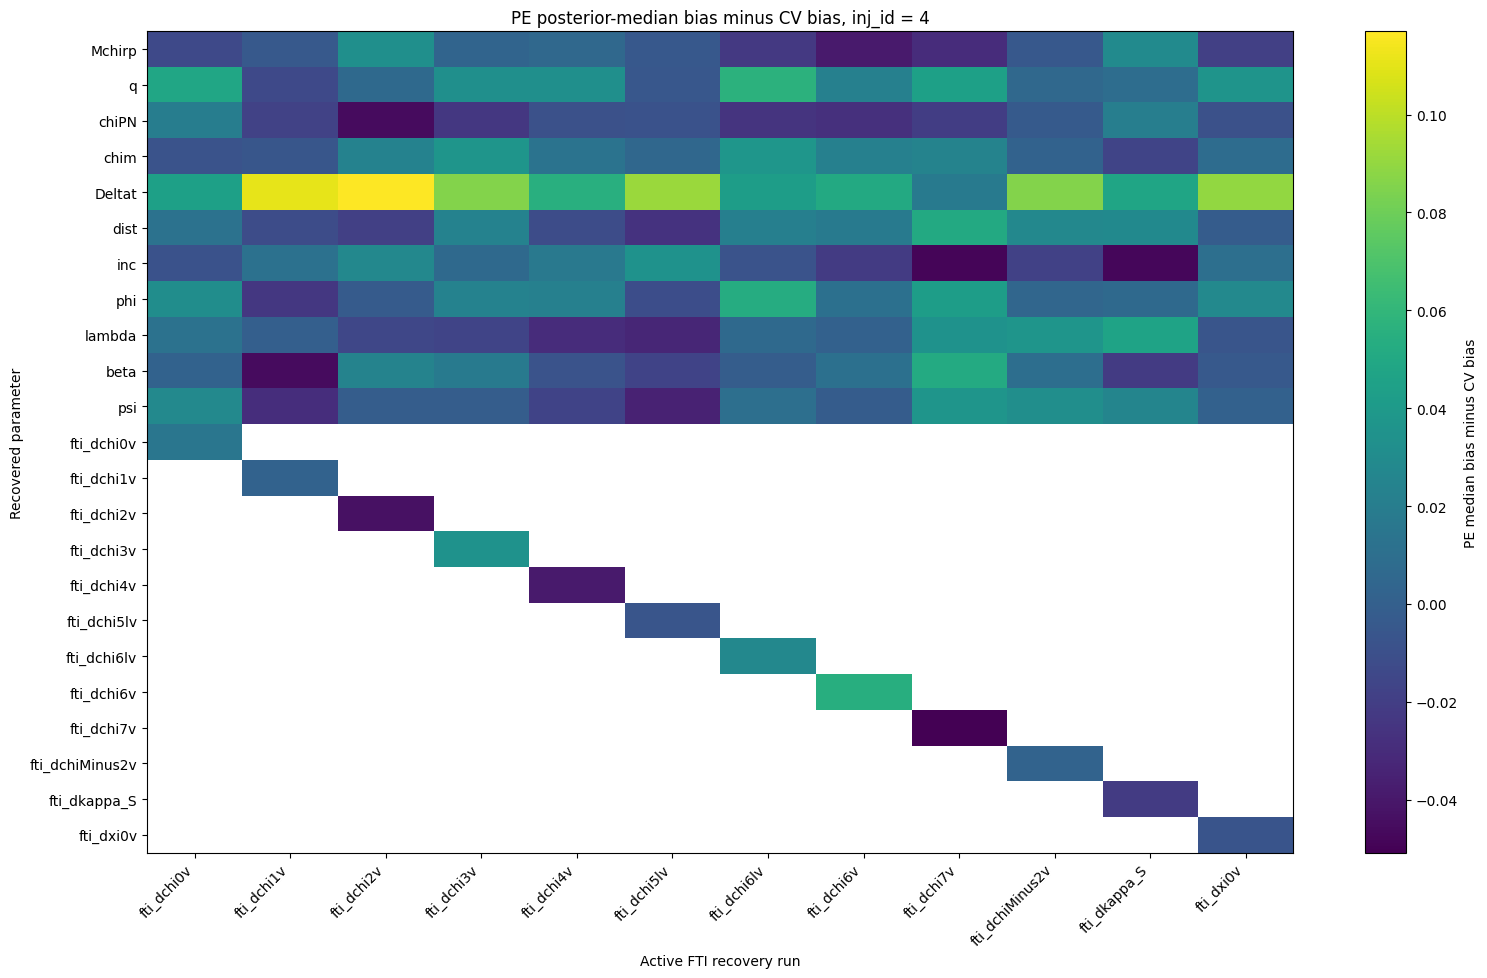

Saved: /pbs/home/a/amahdi/PE_for_my_work/Comparison/cv_vs_median_pe_comparison_inj_id_4/heatmap_median_pe_minus_cv_inj_id_4.png


In [11]:

parameter_order = physical_parameter_order + run_order

difference_matrix = comparison.pivot(
    index="parameter",
    columns="active_fti_run",
    values="median_PE_minus_CV",
).reindex(
    index=parameter_order,
    columns=run_order,
)

masked = np.ma.masked_invalid(
    difference_matrix.to_numpy(dtype=float)
)

fig_height = max(8, 0.43 * len(difference_matrix.index))
fig, ax = plt.subplots(figsize=(16, fig_height))

image = ax.imshow(masked, aspect="auto")

ax.set_xticks(np.arange(len(difference_matrix.columns)))
ax.set_xticklabels(
    difference_matrix.columns,
    rotation=45,
    ha="right",
)

ax.set_yticks(np.arange(len(difference_matrix.index)))
ax.set_yticklabels(difference_matrix.index)

ax.set_xlabel("Active FTI recovery run")
ax.set_ylabel("Recovered parameter")
ax.set_title(
    f"PE posterior-median bias minus CV bias, inj_id = {INJ_ID}"
)

fig.colorbar(
    image,
    ax=ax,
    label="PE median bias minus CV bias",
)

fig.tight_layout()

heatmap_path = (
    OUTPUT_DIR
    / f"heatmap_median_pe_minus_cv_inj_id_{INJ_ID}.png"
)
fig.savefig(heatmap_path, dpi=200, bbox_inches="tight")
plt.show()

print(f"Saved: {heatmap_path.resolve()}")



## 9. Agreement statistics for each corresponding FTI case


In [12]:

def safe_pearson(group):
    x = group["CV_bias_over_sigma"].to_numpy(dtype=float)
    y = group["median_PE_bias_over_sigma"].to_numpy(dtype=float)

    if len(x) < 2 or np.std(x) == 0 or np.std(y) == 0:
        return np.nan

    return np.corrcoef(x, y)[0, 1]


summary_rows = []

for run_name, group in comparison.groupby(
    "active_fti_run",
    sort=False,
):
    difference = group["median_PE_minus_CV"].to_numpy(dtype=float)
    largest_index = group["absolute_difference"].idxmax()
    largest_row = group.loc[largest_index]

    summary_rows.append(
        {
            "active_fti_run": run_name,
            "n_parameters": len(group),
            "mean_absolute_difference": np.mean(np.abs(difference)),
            "RMSE": np.sqrt(np.mean(difference**2)),
            "Pearson_correlation": safe_pearson(group),
            "sign_agreement_fraction": group["same_sign"].mean(),
            "maximum_absolute_difference": largest_row[
                "absolute_difference"
            ],
            "parameter_with_maximum_difference": largest_row[
                "parameter"
            ],
        }
    )

run_summary = pd.DataFrame(summary_rows)

run_summary_path = (
    OUTPUT_DIR
    / f"summary_by_fti_run_cv_vs_median_pe_inj_id_{INJ_ID}.csv"
)
run_summary.to_csv(run_summary_path, index=False)

display(run_summary)
print(f"Saved: {run_summary_path.resolve()}")


,active_fti_run,n_parameters,mean_absolute_difference,RMSE,Pearson_correlation,sign_agreement_fraction,maximum_absolute_difference,parameter_with_maximum_difference
0,fti_dchi0v,12,0.020364,0.024771,-0.441975,0.833333,0.048198,q
1,fti_dchi1v,12,0.023044,0.037185,-0.852020,0.333333,0.110683,Deltat
2,fti_dchi2v,12,0.029872,0.042112,-0.757124,0.250000,0.117026,Deltat
3,fti_dchi3v,12,0.025556,0.033292,-0.635551,0.500000,0.085623,Deltat
4,fti_dchi4v,12,0.021611,0.025801,-0.489447,0.333333,0.054827,Deltat
5,fti_dchi5lv,12,0.023183,0.033126,-0.737989,0.166667,0.091794,Deltat
6,fti_dchi6lv,12,0.026188,0.031486,-0.192990,0.416667,0.056734,q
7,fti_dchi6v,12,0.023448,0.028689,-0.401338,0.583333,0.054341,fti_dchi6v
8,fti_dchi7v,12,0.037761,0.039581,-0.049034,0.500000,0.052056,beta
9,fti_dchiMinus2v,12,0.019484,0.030341,-0.838287,0.500000,0.085694,Deltat


Saved: /pbs/home/a/amahdi/PE_for_my_work/Comparison/cv_vs_median_pe_comparison_inj_id_4/summary_by_fti_run_cv_vs_median_pe_inj_id_4.csv



## 10. Rows with the largest disagreement


In [13]:

largest_disagreements = comparison.nlargest(
    20,
    "absolute_difference",
)[
    [
        "active_fti_run",
        "parameter",
        "CV_bias_over_sigma",
        "median_PE_bias_over_sigma",
        "median_PE_minus_CV",
        "absolute_difference",
        "CV_delta_theta",
        "median_PE_delta_theta",
        "sigma_CV",
        "sigma_PE",
        "sigma_PE_over_sigma_CV",
    ]
]

largest_path = (
    OUTPUT_DIR
    / f"largest_cv_vs_median_pe_disagreements_inj_id_{INJ_ID}.csv"
)
largest_disagreements.to_csv(largest_path, index=False)

display(largest_disagreements)
print(f"Saved: {largest_path.resolve()}")


,active_fti_run,parameter,CV_bias_over_sigma,median_PE_bias_over_sigma,median_PE_minus_CV,absolute_difference,CV_delta_theta,median_PE_delta_theta,sigma_CV,sigma_PE,sigma_PE_over_sigma_CV
28,fti_dchi2v,Deltat,-8.027428e-04,0.116223,0.117026,0.117026,-7.586292e-05,0.011042,0.094505,0.095009,1.005333
16,fti_dchi1v,Deltat,-8.192647e-04,0.109863,0.110683,0.110683,-7.587191e-05,0.010140,0.092610,0.092296,0.996615
64,fti_dchi5lv,Deltat,-7.198464e-04,0.091074,0.091794,0.091794,-7.584591e-05,0.009753,0.105364,0.107086,1.016343
136,fti_dxi0v,Deltat,-7.938828e-04,0.089278,0.090072,0.090072,-7.585397e-05,0.008715,0.095548,0.097614,1.021620
112,fti_dchiMinus2v,Deltat,-8.441221e-04,0.084850,0.085694,0.085694,-7.591032e-05,0.007854,0.089928,0.092568,1.029357
40,fti_dchi3v,Deltat,-7.761340e-04,0.084846,0.085623,0.085623,-7.585237e-05,0.008387,0.097731,0.098854,1.011495
73,fti_dchi6lv,q,2.007675e-06,0.056736,0.056734,0.056734,1.045385e-08,0.000298,0.005207,0.005247,1.007633
52,fti_dchi4v,Deltat,-7.462229e-04,0.054080,0.054827,0.054827,-7.584594e-05,0.005504,0.101640,0.101783,1.001411
95,fti_dchi6v,fti_dchi6v,-9.182326e-07,0.054340,0.054341,0.054341,-5.762038e-09,0.000344,0.006275,0.006328,1.008447
79,fti_dchi6lv,phi,1.134633e-04,0.053504,0.053391,0.053391,1.796211e-06,0.000855,0.015831,0.015978,1.009301


Saved: /pbs/home/a/amahdi/PE_for_my_work/Comparison/cv_vs_median_pe_comparison_inj_id_4/largest_cv_vs_median_pe_disagreements_inj_id_4.csv



## Interpretation

The normalized quantities may disagree because of differences in either or both of the following:

1. the CV linearized parameter displacement and the actual posterior-median displacement;
2. the Fisher uncertainty `sigma_CV` and the PE posterior uncertainty `sigma_PE`.

The complete output table therefore retains both raw displacements and both uncertainties, rather than comparing only the final normalized ratios.


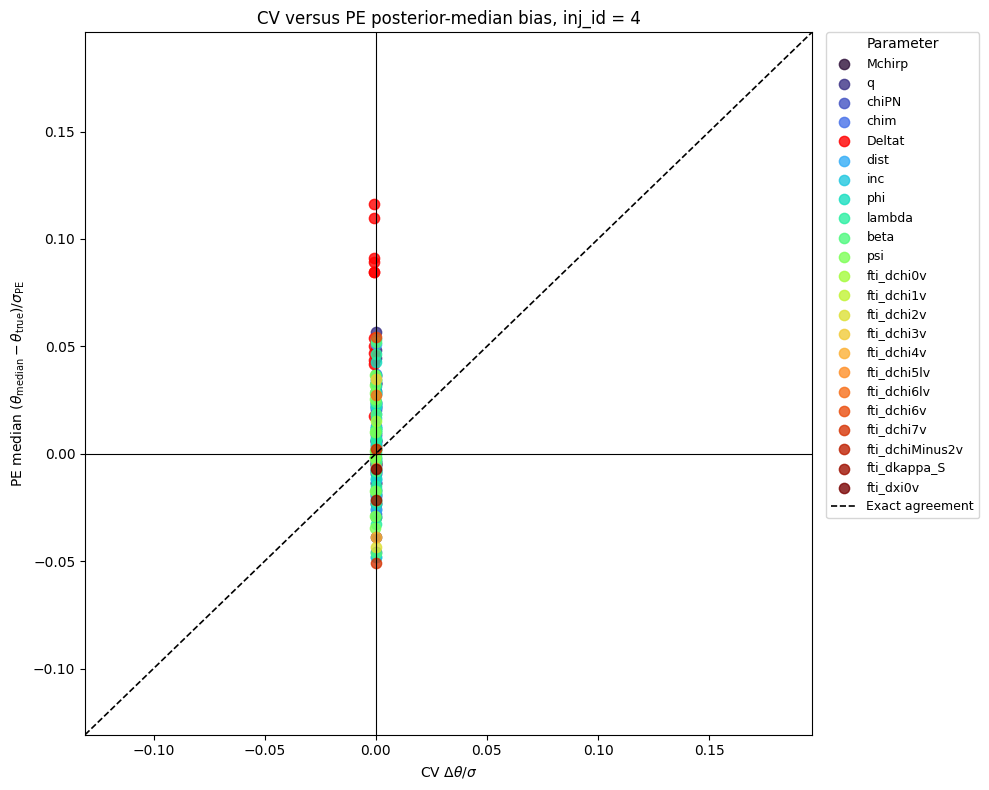

Saved: /pbs/home/a/amahdi/PE_for_my_work/Comparison/cv_vs_median_pe_comparison_inj_id_4/scatter_cv_vs_median_pe_by_parameter_inj_id_4.png


In [14]:
# Keep only finite values while retaining the parameter labels
plot_data = comparison[
    [
        "CV_bias_over_sigma",
        "median_PE_bias_over_sigma",
        "parameter",
    ]
].copy()

finite = (
    np.isfinite(plot_data["CV_bias_over_sigma"])
    & np.isfinite(plot_data["median_PE_bias_over_sigma"])
)

plot_data = plot_data.loc[finite].copy()

# Unique recovered parameters
parameters = plot_data["parameter"].unique().tolist()

# Generate a different color for each parameter
cmap = plt.colormaps["turbo"].resampled(len(parameters))

parameter_colors = {
    parameter: cmap(index)
    for index, parameter in enumerate(parameters)
}

# Force all Deltat points to be red
parameter_colors["Deltat"] = "red"


# Determine common limits for both axes
lower = min(
    plot_data["CV_bias_over_sigma"].min(),
    plot_data["median_PE_bias_over_sigma"].min(),
)

upper = max(
    plot_data["CV_bias_over_sigma"].max(),
    plot_data["median_PE_bias_over_sigma"].max(),
)

padding = 0.08 * max(upper - lower, 1.0)
limits = (lower - padding, upper + padding)


# Create the scatter plot
fig, ax = plt.subplots(figsize=(10, 8))

for parameter in parameters:
    parameter_data = plot_data.loc[
        plot_data["parameter"] == parameter
    ]

    ax.scatter(
        parameter_data["CV_bias_over_sigma"],
        parameter_data["median_PE_bias_over_sigma"],
        color=parameter_colors[parameter],
        label=parameter,
        s=55,
        alpha=0.8,
    )


# Exact-agreement diagonal
ax.plot(
    limits,
    limits,
    color="black",
    linestyle="--",
    linewidth=1.2,
    label="Exact agreement",
)

ax.axhline(
    0,
    color="black",
    linewidth=0.8,
)

ax.axvline(
    0,
    color="black",
    linewidth=0.8,
)

ax.set_xlim(limits)
ax.set_ylim(limits)

ax.set_xlabel(r"CV $\Delta\theta/\sigma$")

ax.set_ylabel(
    r"PE median "
    r"$(\theta_{\mathrm{median}}-\theta_{\mathrm{true}})"
    r"/\sigma_{\mathrm{PE}}$"
)

ax.set_title(
    f"CV versus PE posterior-median bias, inj_id = {INJ_ID}"
)

# Put the large parameter legend outside the plotting region
ax.legend(
    title="Parameter",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    borderaxespad=0,
    fontsize=9,
)

fig.tight_layout()

scatter_path = (
    OUTPUT_DIR
    / f"scatter_cv_vs_median_pe_by_parameter_inj_id_{INJ_ID}.png"
)

fig.savefig(
    scatter_path,
    dpi=200,
    bbox_inches="tight",
)

plt.show()

print(f"Saved: {scatter_path.resolve()}")